# Error de traslación de los loops — StereoLoopDetector en FieldSAFE

Para cada loop detectado (query `q`, match `m`) se compara la magnitud de la traslación estimada por PnP
(`loop_translation_x/y/z`, en el frame de la cámara) contra la distancia GPS planar entre ambos frames

Se compara solo la magnitud porque el ground truth no tiene orientación y el detector descarta la rotación de PnP.

Corridas con `--frequency 10` (frecuencia nominal de la cámara) sobre las 3 sesiones de FieldSAFE:
dinámica #1, estática #1 y dinámica #2.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')  # evaluation/, donde está commons.py
from commons import load_results, load_ground_truth, translation_errors

RESULTS = Path('.')  # evaluation/finalRuns/originales_paper, donde están los .yml de las corridas
PREPARED = Path('/mnt/datalake/datasets/fieldsafe/prepared')
FREQ = 10
SESSIONS = {  # nombre -> sesión de FieldSAFE
    'Dinámica #1': ('dynamic1', '2016-10-25-11-41-21'),
    'Estática #1': ('static1', '2016-10-25-11-09-42'),
    'Dinámica #2': ('dynamic2', '2016-10-25-12-07-22'),
}

In [2]:
def load_session(key, session):
    res, q, m, t_est = load_results(RESULTS / f'fs_{key}_results.yml')
    xy = load_ground_truth(PREPARED / f'poses_{session}.csv', num_images=res['num_images'])
    return res, xy, q, m, t_est

data = {}
for label, (key, session) in SESSIONS.items():
    res, xy, q, m, t_est = load_session(key, session)
    err, stopped = translation_errors(xy, q, m, t_est)
    data[label] = dict(res=res, err=err, stopped=stopped)
    print(f"{label}: {res['num_images']} imágenes, {len(q)} loops")

Dinámica #1: 11363 imágenes, 197 loops
Estática #1: 9475 imágenes, 198 loops
Dinámica #2: 12182 imágenes, 122 loops


In [3]:
def groups_of(d):
    e, s = d['err'], d['stopped']
    return [('Todos', e), ('En movimiento', e[~s]), ('Detenido', e[s])]

print(f"{'Sesión':<13} {'Grupo':<14} {'n':>4} {'media [m]':>10} {'mediana [m]':>12} {'p90 [m]':>8} {'max [m]':>8}")
for label, d in data.items():
    for name, e in groups_of(d):
        if len(e):
            print(f"{label:<13} {name:<14} {len(e):4d} {e.mean():10.3f} {np.median(e):12.3f} "
                  f"{np.percentile(e, 90):8.3f} {e.max():8.3f}")
        else:
            print(f"{label:<13} {name:<14} {0:4d} {'—':>10} {'—':>12} {'—':>8} {'—':>8}")

Sesión        Grupo             n  media [m]  mediana [m]  p90 [m]  max [m]
Dinámica #1   Todos           197      0.208        0.151    0.433    1.038
Dinámica #1   En movimiento    65      0.331        0.279    0.800    1.038
Dinámica #1   Detenido        132      0.148        0.150    0.159    0.173
Estática #1   Todos           198      0.221        0.148    0.180    8.852
Estática #1   En movimiento     8      0.686        0.142    1.745    4.193
Estática #1   Detenido        190      0.202        0.149    0.167    8.852
Dinámica #2   Todos           122      0.147        0.152    0.162    0.496
Dinámica #2   En movimiento     2      0.308        0.308    0.458    0.496
Dinámica #2   Detenido        120      0.144        0.152    0.162    0.168


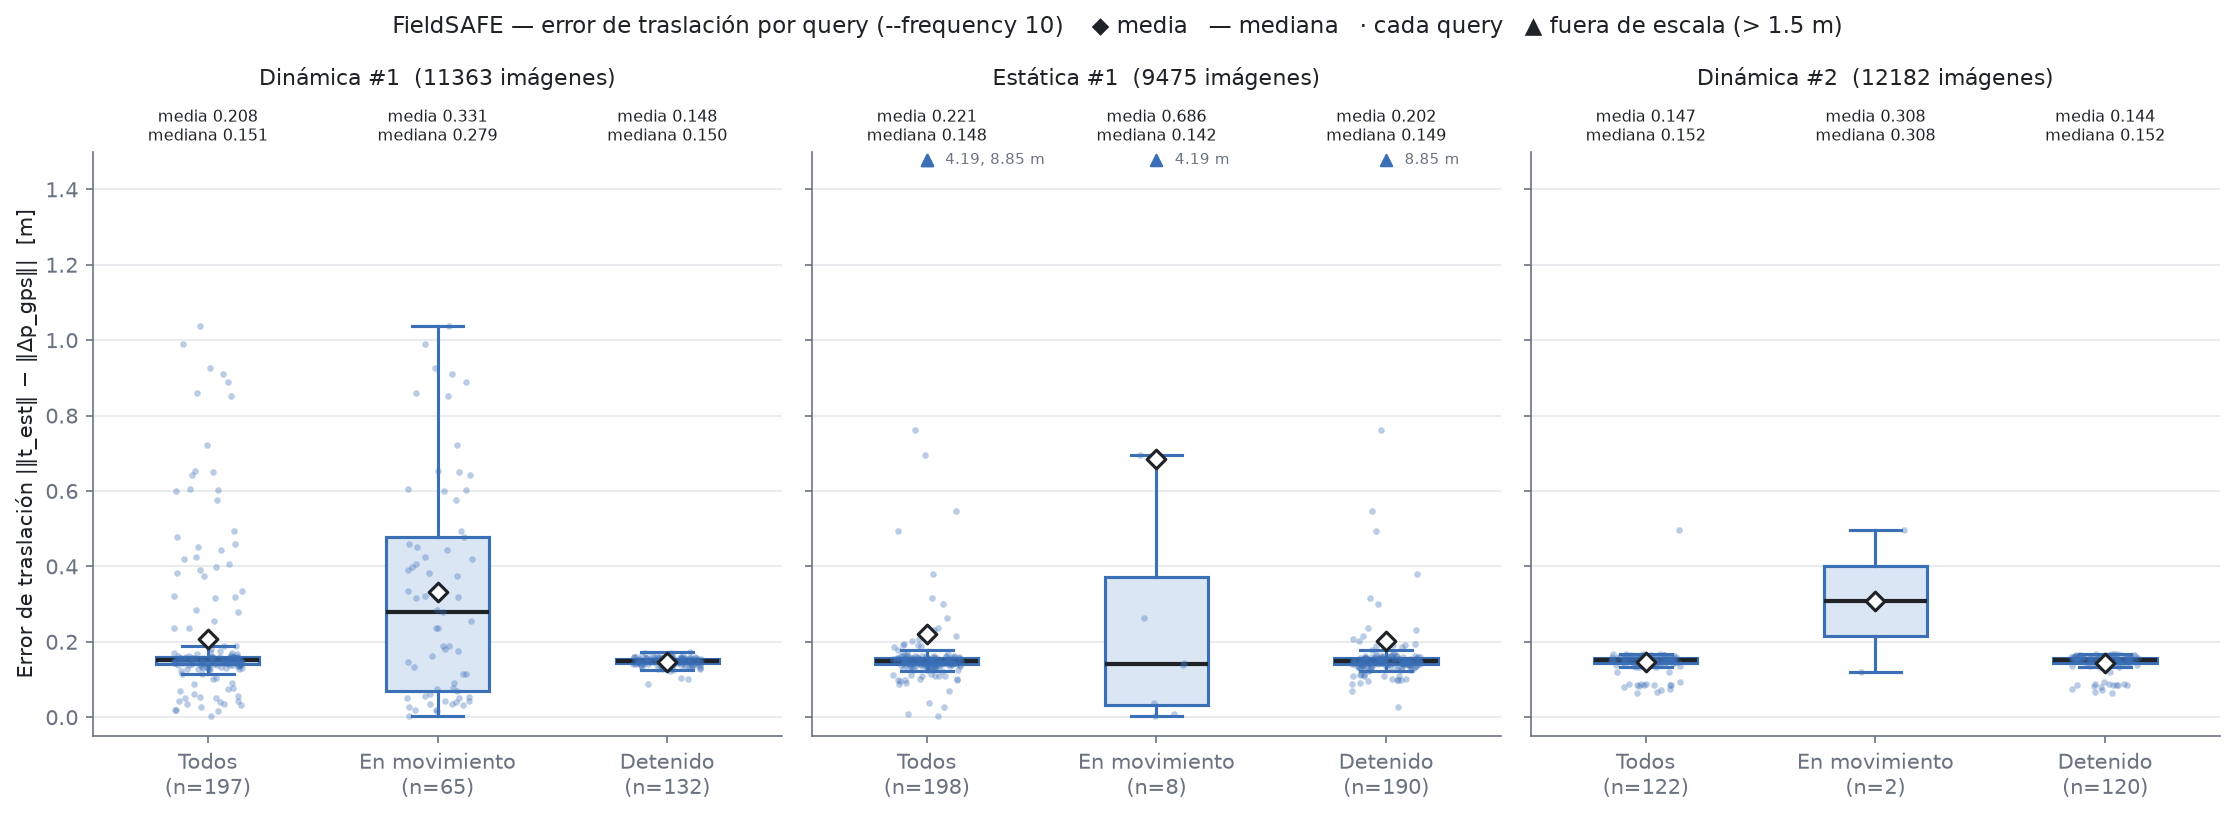

In [4]:
box_color, ink, muted = '#3b6fb6', '#1f2328', '#6b7280'
Y_MAX = 1.5  # m; los puntos por encima se marcan con ▲ en el borde
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 5.5), dpi=150, sharey=True)
for ax, (label, d) in zip(np.atleast_1d(axes), data.items()):
    groups = [(n, e) for n, e in groups_of(d) if len(e)]
    if groups:
        ax.boxplot([e for _, e in groups], widths=0.45, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor='#dbe6f5', edgecolor=box_color, linewidth=1.5),
                   medianprops=dict(color=ink, linewidth=2),
                   whiskerprops=dict(color=box_color, linewidth=1.5),
                   capprops=dict(color=box_color, linewidth=1.5))
        for i, (_, e) in enumerate(groups, start=1):
            jitter = i + rng.uniform(-0.15, 0.15, len(e))
            inside = e <= Y_MAX
            ax.scatter(jitter[inside], e[inside], s=10, color=box_color, alpha=0.35, linewidths=0, zorder=3)
            if (~inside).any():
                ax.scatter(np.full((~inside).sum(), i), np.full((~inside).sum(), Y_MAX * 0.985), marker='^', s=30,
                           color=box_color, zorder=3, clip_on=False)
                ax.annotate(', '.join(f"{v:.2f}" for v in np.sort(e[~inside])) + ' m', (i + 0.08, Y_MAX * 0.985),
                            fontsize=7, color=muted, va='center')
            ax.scatter(i, e.mean(), marker='D', s=40, color='white', edgecolor=ink, linewidths=1.5, zorder=4)
            ax.annotate(f"media {e.mean():.3f}\nmediana {np.median(e):.3f}", (i, 1.01),
                        xycoords=('data', 'axes fraction'), ha='center', va='bottom', fontsize=7.5, color=ink,
                        annotation_clip=False)
        ax.set_xticks(range(1, len(groups) + 1), [f"{n}\n(n={len(e)})" for n, e in groups])
    else:
        ax.text(0.5, 0.5, 'sin loops detectados', transform=ax.transAxes, ha='center', color=muted)
        ax.set_xticks([])
    ax.set_ylim(-0.05, Y_MAX)
    ax.set_title(f"{label}  ({d['res']['num_images']} imágenes)", fontsize=10.5, color=ink, pad=32)
    ax.grid(axis='y', color='#e5e7eb', linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(muted)
    ax.tick_params(colors=muted)

np.atleast_1d(axes)[0].set_ylabel('Error de traslación |‖t_est‖ − ‖Δp_gps‖|  [m]', color=ink)
fig.suptitle(f"FieldSAFE — error de traslación por query (--frequency {FREQ})    "
             f"◆ media   — mediana   · cada query   ▲ fuera de escala (> {Y_MAX} m)", fontsize=11, color=ink)
fig.tight_layout()
# plt.show()